# Compare c-GC vs c-GC-star Methods

This notebook loads transition metrics from both c-GC and c-GC-star methods and creates overlay plots comparing edge counts across n_pasts (P values) for each fish dataset.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CAUSALISED_GC_RELATIVE_PATH = Path('src/markovianity_diagnostic/core/causalised-GC.py')
PROJECT_ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (p / CAUSALISED_GC_RELATIVE_PATH).exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find '{CAUSALISED_GC_RELATIVE_PATH}' from {Path.cwd().resolve()}"
    )

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics


In [2]:
# Load transition data from both methods
c_gc_transitions_path = PROJECT_ROOT / 'outputs' / 'v2a-RSNs' / 'c-GC' / 'transitions.csv'
c_gc_star_transitions_path = PROJECT_ROOT / 'outputs' / 'v2a-RSNs' / 'c-GC-star' / 'transitions.csv'

print(f"Loading c-GC transitions from: {c_gc_transitions_path}")
print(f"Loading c-GC-star transitions from: {c_gc_star_transitions_path}")

c_gc_df = pd.read_csv(c_gc_transitions_path)
c_gc_star_df = pd.read_csv(c_gc_star_transitions_path)

# Add method column for identification
c_gc_df['method'] = 'c-GC'
c_gc_star_df['method'] = 'c-GC-star'

# Map dataset names to fish-1, fish-2, etc.
unique_datasets = sorted(c_gc_df['dataset'].unique())
dataset_mapping = {name: f'fish-{i+1}' for i, name in enumerate(unique_datasets)}

c_gc_df['dataset'] = c_gc_df['dataset'].map(dataset_mapping)
c_gc_star_df['dataset'] = c_gc_star_df['dataset'].map(dataset_mapping)

print(f"\nc-GC data shape: {c_gc_df.shape}")
print(f"c-GC-star data shape: {c_gc_star_df.shape}")
print(f"\nDatasets: {sorted(c_gc_df['dataset'].unique())}")

Loading c-GC transitions from: /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics/outputs/v2a-RSNs/c-GC/transitions.csv
Loading c-GC-star transitions from: /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics/outputs/v2a-RSNs/c-GC-star/transitions.csv

c-GC data shape: (28, 8)
c-GC-star data shape: (28, 8)

Datasets: ['fish-1', 'fish-2', 'fish-3', 'fish-4']


Saved overlay plot to: /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics/outputs/v2a-RSNs/c-GC_vs_c-GC*_overlay.png


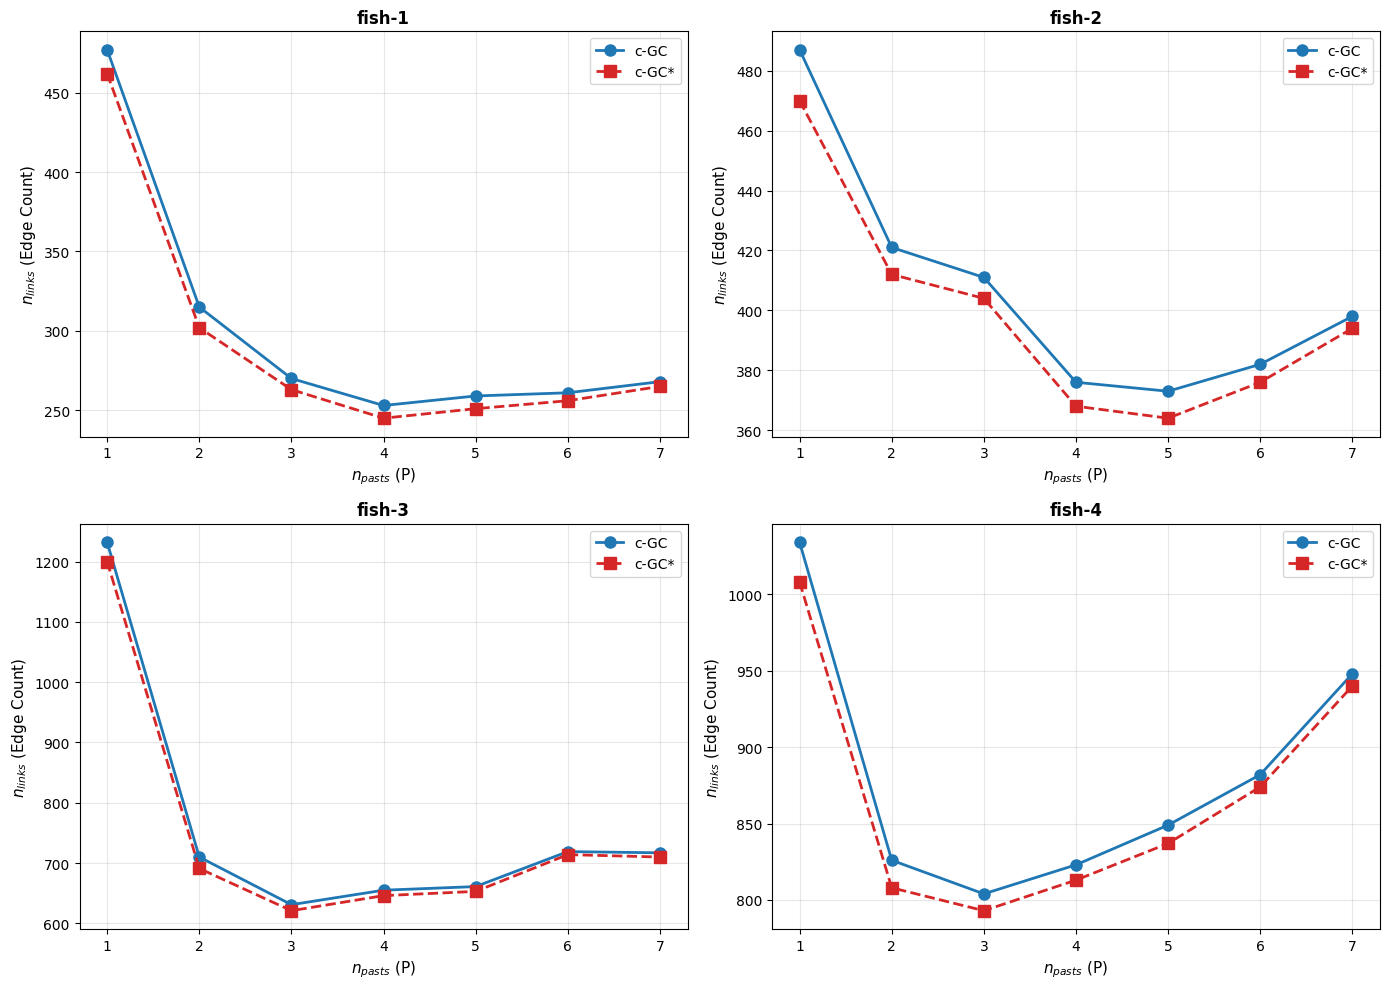

In [3]:
# Create overlay plots for each dataset
datasets = sorted(c_gc_df['dataset'].unique())
n_datasets = len(datasets)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = {'c-GC': 'tab:blue', 'c-GC*': 'tab:red'}
markers = {'c-GC': 'o', 'c-GC*': 's'}
linestyles = {'c-GC': '-', 'c-GC*': '--'}

for idx, dataset in enumerate(datasets):
    ax = axes[idx]
    
    # Get data for this dataset from both methods
    c_gc_dataset = c_gc_df[c_gc_df['dataset'] == dataset].sort_values('P')
    c_gc_star_dataset = c_gc_star_df[c_gc_star_df['dataset'] == dataset].sort_values('P')
    
    # Plot c-GC
    ax.plot(
        c_gc_dataset['P'],
        c_gc_dataset['edge_count'],
        marker=markers['c-GC'],
        color=colors['c-GC'],
        linestyle=linestyles['c-GC'],
        label='c-GC',
        linewidth=2,
        markersize=8,
    )
    
    # Plot c-GC*
    ax.plot(
        c_gc_star_dataset['P'],
        c_gc_star_dataset['edge_count'],
        marker=markers['c-GC*'],
        color=colors['c-GC*'],
        linestyle=linestyles['c-GC*'],
        label='c-GC*',
        linewidth=2,
        markersize=8,
    )
    
    ax.set_xlabel('$n_{pasts}$ (P)', fontsize=11)
    ax.set_ylabel('$n_{links}$ (Edge Count)', fontsize=11)
    ax.set_title(f'{dataset}', fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, 8))
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / 'outputs' / 'v2a-RSNs' / 'c-GC_vs_c-GC*_overlay.png',
    dpi=200,
    bbox_inches='tight'
)
print(f"Saved overlay plot to: {PROJECT_ROOT / 'outputs' / 'v2a-RSNs' / 'c-GC_vs_c-GC*_overlay.png'}")
plt.show()

Saved combined plot to: /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics/outputs/v2a-RSNs/c-GC_vs_c-GC*_combined.png


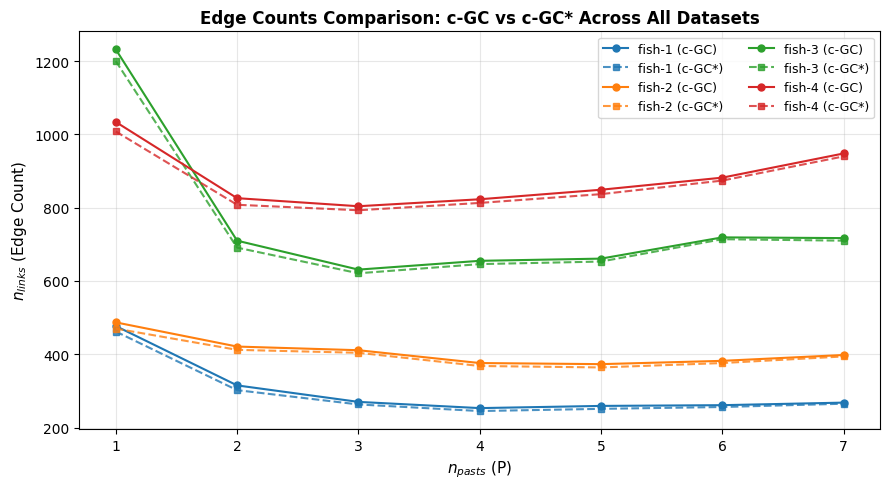

In [ ]:
# Create a single combined plot with all datasets overlaid
fig, ax = plt.subplots(figsize=(9, 5))

# Get unique datasets sorted
datasets = sorted(c_gc_df['dataset'].unique())
colors_dataset = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for idx, dataset in enumerate(datasets):
    c_gc_dataset = c_gc_df[c_gc_df['dataset'] == dataset].sort_values('P')
    c_gc_star_dataset = c_gc_star_df[c_gc_star_df['dataset'] == dataset].sort_values('P')
    
    # Plot c-GC with solid line
    ax.plot(
        c_gc_dataset['P'],
        c_gc_dataset['edge_count'],
        marker='o',
        color=colors_dataset[idx],
        linestyle='-',
        label=f'{dataset} (c-GC)',
        linewidth=1.5,
        markersize=5,
    )
    
    # Plot c-GC* with dashed line
    ax.plot(
        c_gc_star_dataset['P'],
        c_gc_star_dataset['edge_count'],
        marker='s',
        color=colors_dataset[idx],
        linestyle='--',
        label=f'{dataset} (c-GC*)',
        linewidth=1.5,
        markersize=5,
        alpha=0.8,
    )

ax.set_xlabel('$n_{pasts}$ (P)', fontsize=11)
ax.set_ylabel('$n_{links}$ (Edge Count)', fontsize=11)
ax.set_title('Edge Counts Comparison: c-GC vs c-GC* Across All Datasets', fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 8))
ax.legend(fontsize=9, loc='best', ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / 'outputs' / 'v2a-RSNs' / 'c-GC_vs_c-GC*_combined.png',
    dpi=200,
    bbox_inches='tight'
)
print(f"Saved combined plot to: {PROJECT_ROOT / 'outputs' / 'v2a-RSNs' / 'c-GC_vs_c-GC*_combined.png'}")
plt.show()


In [5]:
# Compute summary statistics comparing the two methods
print("Summary Statistics: c-GC vs c-GC*\n")
print("="*70)

# Merge data for comparison
comparison_df = pd.merge(
    c_gc_df,
    c_gc_star_df,
    on=['dataset', 'P', 'file'],
    suffixes=('_c_gc', '_c_gc_star')
)

comparison_df['edge_count_diff'] = (
    comparison_df['edge_count_c_gc_star'] - comparison_df['edge_count_c_gc']
)
comparison_df['percent_diff'] = (
    100 * comparison_df['edge_count_diff'] / comparison_df['edge_count_c_gc']
)

for dataset in sorted(comparison_df['dataset'].unique()):
    dataset_data = comparison_df[comparison_df['dataset'] == dataset]
    print(f"\n{dataset}:")
    print(f"  Mean edge count difference: {dataset_data['edge_count_diff'].mean():.2f}")
    print(f"  Mean percent difference: {dataset_data['percent_diff'].mean():.2f}%")
    print(f"  Max difference: {dataset_data['edge_count_diff'].max():.0f} (at P={dataset_data.loc[dataset_data['edge_count_diff'].idxmax(), 'P']:.0f})")
    print(f"  Min difference: {dataset_data['edge_count_diff'].min():.0f} (at P={dataset_data.loc[dataset_data['edge_count_diff'].idxmin(), 'P']:.0f})")

print(f"\n" + "="*70)
print(f"\nOverall Statistics:")
print(f"  Mean edge count difference (all): {comparison_df['edge_count_diff'].mean():.2f}")
print(f"  Mean percent difference (all): {comparison_df['percent_diff'].mean():.2f}%")

Summary Statistics: c-GC vs c-GC*


fish-1:
  Mean edge count difference: -8.43
  Mean percent difference: -2.74%
  Max difference: -3 (at P=7)
  Min difference: -15 (at P=1)

fish-2:
  Mean edge count difference: -8.57
  Mean percent difference: -2.06%
  Max difference: -4 (at P=7)
  Min difference: -17 (at P=1)

fish-3:
  Mean edge count difference: -12.86
  Mean percent difference: -1.59%
  Max difference: -5 (at P=6)
  Min difference: -32 (at P=1)

fish-4:
  Mean edge count difference: -13.29
  Mean percent difference: -1.49%
  Max difference: -8 (at P=6)
  Min difference: -26 (at P=1)


Overall Statistics:
  Mean edge count difference (all): -10.79
  Mean percent difference (all): -1.97%
